# Triazole residence time in Lake Geneva

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from IPython.display import Image, display


# Uncomment for interactive plots:
%matplotlib widget 

### The problem

During the summer of 2025, 1,2,4-triazole has been detected in drinking water from Lake Geneva with concentrations ~0.7 µg/l, which is above the recommended threshold of 0.1 µg/l. The main source of triazole seems to be an industrial site in Monthey that is discharging the contaminant to the Rhône River entering Lake Geneva. The concentration profile below has been taken at the center of the lake (SHL2):

Text(0.5, 0, 'Conc [$\\mu$g/l]')

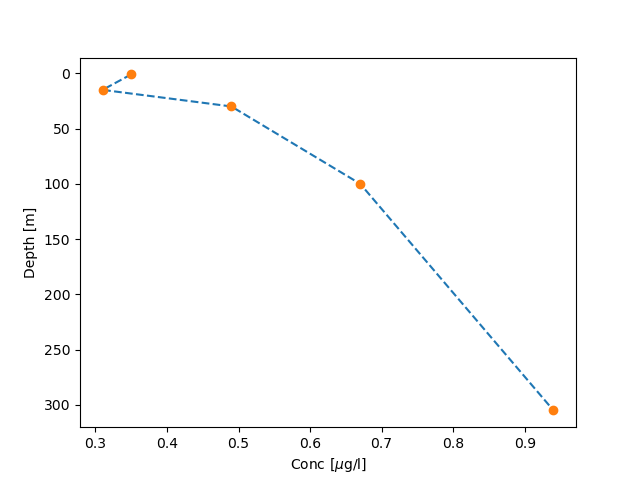

In [11]:
depth=np.array([1,15,30,100,305])
conc=np.array([0.35,0.31,0.49,0.67,0.94])
depth_interp=np.arange(1,305,1)
conc_interp=np.interp(depth_interp,depth,conc)

plt.figure()
plt.plot(conc_interp,depth_interp,'--')
plt.plot(conc,depth,'o')
plt.gca().invert_yaxis()
plt.gca().set_ylabel("Depth [m]")
plt.gca().set_xlabel("Conc [$\mu$g/l]")

The question we want to answer with this simple model:

*If we stop the input, how long would it take to go back to the recommended concentration of 0.1 µg/l for different mixing scenarios?*

The model applies the following scenarios:
- No mixing between the epilimnion and hypolimnion
- Mixing every $\Delta t$ years (with $\Delta t=1, 5, 10$ years?) 
- Mixing occuring at frequency based on the past probabilistic distribution of mixing events

### The two-box model

We represent Lake Geneva with two boxes: one for the epilimnion with a depth-averaged triazole concentration $C_{epi}$, one for the hypolimnion with a depth-averaged triazole concentration $C_{hypo}$ (see the schematic below). 
The inflow discharge $Q$ is assumed constant over time and equal to the outflow discharge $Q=250\text{ m}^3\text{/s}$. Part of the inflow goes into the epilimnion ($Q_{epi}$), the other part to the hypolimnion ($Q_{hypo}$). The vertical distribution of the inflow is based on estimations from the Rhône density and entrainment over a yearly cycle. No input of triazole is considered ($C_{in}=0$), which means that the Rhône dilutes the triazole concentration in the lake. To fulfill volume conservation, a diffusive mass flux $M_{diff}$ generated by $Q_{hypo}$ is applied from the hypolimnion to the epilimnion.
The volume of the boxes is changing over time according to changes in the epilimion depth $h_{epi}(t)$. Those volume changes mix triazole between the two boxes (mass flux $M_{mix,epi}$ from the hypolimnion to the epilimnion and mass flux $M_{mix,hypo}$ in the opposite direction).


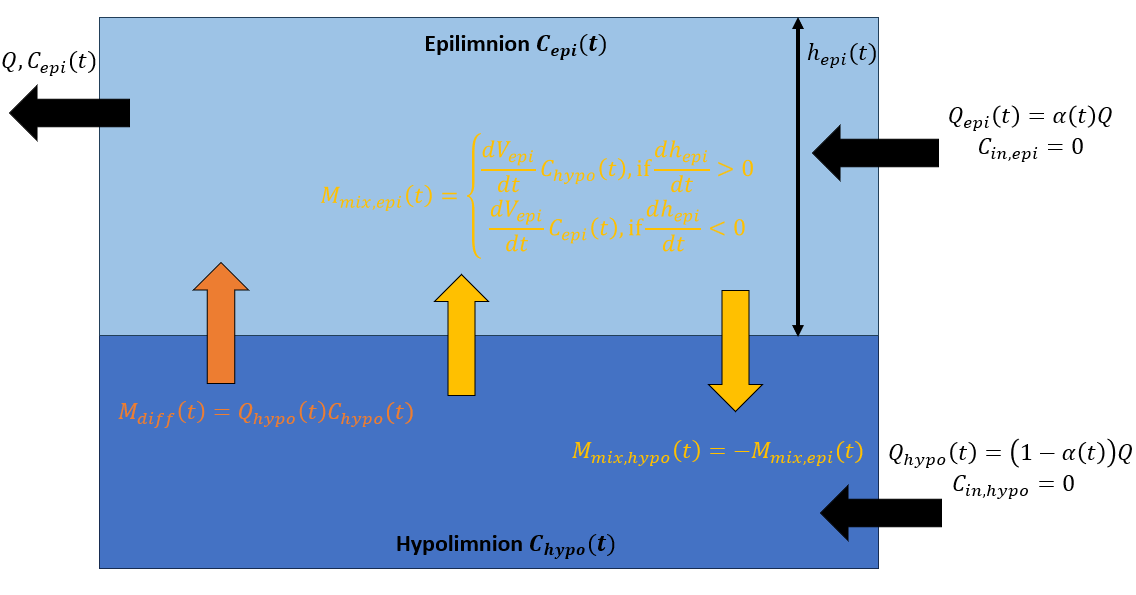

In [12]:
display(Image(filename="Schematic.png",width=800))

### Scenario selection & epilimnion depth time series

Choose the time series of epilimnion depth to use for the residence time calculation.

In [ ]:
# filename_epi=""
# df_hepi=pd.read_csv(os.path.join("..","..","data","hepi",filename_epi))
hepi=np.full(10,100) # [m]
tyr=np.arange(0,10,1) # [yr]

### Box volumes

Import lake hypsometry

In [28]:
df_hypso=pd.read_csv(os.path.join("..","..","data","morphology","Lake_Geneva_morphology.csv"))

Computes the volume of the two boxes (epilimnion and hypolimnion) based on the epilimnion depth and the morphology of Lake Geneva. 

In [ ]:
Vepi=np.full(len(hepi),np.nan)
Vhypo=np.full(len(hepi),np.nan)

for kt in range(len(hepi)):
    Vhypo[kt]=np.interp(hepi[kt],df_hypso["Depth (m)"],df_hypso["Volume (m3)"]) # [m3]
    Vepi[kt]=df_hypso["Volume (m3)"][0]-Vhypo[kt] # [m3]

### Variable initiation

### Derivation of the equations

A mass balance on the hypolimnion gives:
$$V_{hypo}\frac{\partial C_{hypo}(t)}{\partial t}=Q\,C_{in}-Q\,C_{hypo}(t)\Leftrightarrow \frac{\partial C_{hypo}(t)}{\partial t}+\frac{1}{\tau}C_{hypo}(t)-\frac{1}{\tau}C_{in}=0\quad (1)$$



Similarly for the epilimnion:
$$V_{epi}\frac{\partial C_{epi}(t)}{\partial t}=Q\,C_{hypo}(t)-Q\,C_{epi}(t)\Leftrightarrow \frac{\partial C_{epi}(t)}{\partial t}+\frac{1}{\tau}C_{epi}(t)-\frac{1}{\tau}C_{hypo}(t)=0\quad (2)$$

### Solutions of the equations

To solve Eq.(1), we multiply both sides by $e^{t/\tau}$:
$$e^{t/\tau}\frac{\partial C_{hypo}(t)}{\partial t}+\frac{e^{t/\tau}}{\tau}C_{hypo}(t)-\frac{e^{t/\tau}}{\tau}C_{in}=0$$
$$\Leftrightarrow\frac{\partial \left(C_{hypo}(t)e^{t/\tau}\right)}{\partial t}=\frac{e^{t/\tau}}{\tau}C_{in}$$
Integrating from $t=0$ to $t$:
$$\left.\left(C_{hypo}(t)e^{t/\tau}\right)\right|_{0}^t=\left.\left(e^{t/\tau}C_{in}\right)\right|_{0}^t$$
$$\Leftrightarrow C_{hypo}(t)= C_{in}+(C_{hypo,0}-C_{in})e^{-t/\tau}\quad (3)$$
Replacing in Eq.(2):
$$\frac{\partial C_{epi}(t)}{\partial t}+\frac{1}{\tau}C_{epi}(t)-\frac{(C_{hypo,0}-C_{in})}{\tau}e^{-t/\tau}-\frac{C_{in}}{\tau}=0$$
Multipyling both sides by $e^{t/\tau}$:
$$\frac{\partial \left(C_{epi}(t)e^{t/\tau}\right)}{\partial t}=\frac{C_{in}}{\tau}e^{t/\tau}+\frac{C_{hypo,0}-C_{in}}{\tau}$$
Integrating from $t=0$ to $t$:
$$\left.\left(C_{epi}(t)e^{t/\tau}\right)\right|_{0}^t=\left.\left(C_{in}e^{t/\tau}\right)\right|_{0}^t+\frac{C_{hypo,0}-C_{in}}{\tau}t$$
$$\Leftrightarrow C_{epi}(t)=C_{in}+\left(C_{epi,0}-C_{in}\right)e^{-t/\tau}+\frac{C_{hypo,0}-C_{in}}{\tau}t\,e^{-t/\tau}\quad (4)$$
The concentrations (3) and (4) can be made dimensionless and independent of $C_0=C_{epi,0}=C_{hypo,0}$ and $C_{in}$ as:
$$\widetilde{C}_{hypo}(t)=\frac{C_{hypo}(t)-C_{0}}{C_{in}-C_{0}}=1-e^{-t/\tau}\quad (5)$$
$$\widetilde{C}_{epi}(t)=\frac{C_{epi}(t)-C_{0}}{C_{in}-C_{0}}=1-e^{-t/\tau}\left(1+\frac{t}{\tau}\right)\quad (6)$$
The difference between the two dimensionless concentrations is:
$$\widetilde{C}_{hypo}(t)-\widetilde{C}_{epi}(t)=\frac{C_{hypo}(t)-C_{epi}(t)}{C_{in}-C_{0}}=\frac{t}{\tau}\,e^{-t/\tau}\quad (7)$$

In [4]:
def Cepi(t_ratio,C0e,C0h,Cin): # For same residence time between epi and hypo and different C0
    return Cin+np.exp(-t_ratio)*(C0e-Cin+t_ratio*(C0h-Cin))

In [5]:
def Chypo(t_ratio,C0h,Cin): 
    return Cin+(C0h-Cin)*np.exp(-t_ratio)

In [6]:
def Cepi_nondim(t_ratio): # (Cepi-C0)/(Cin-C0)
    return 1-t_ratio*np.exp(-t_ratio)-np.exp(-t_ratio)

In [7]:
def Chypo_nondim(t_ratio): # (Chypo-C0)/(Cin-C0)
    return 1-np.exp(-t_ratio)

In [8]:
C0=0 # C0<<Cin
Cin=1 # Slightly higher than bottom concentration
t_ratio=np.arange(0,10,1/100) # t/tau

### Dimensionless concentration time series

Time ratio $t/\tau$:

In [9]:
t_ratio=np.arange(0,10,1/100) # t/tau

Dimensionless values at a certain time:

In [10]:
tau_val=5.5 # [yr]
tf_val=13 # Since last mixing [yr]
Cepi_val=Cepi_nondim(tf_val/tau_val) # (Cepi-C0)/(Cin-C0)
Chypo_val=Chypo_nondim(tf_val/tau_val) # (Chypo-C0)/(Cin-C0)
Dconc_val=Chypo_nondim(tf_val/tau_val)-Cepi_nondim(tf_val/tau_val) # (Chypo-Cepi)/(Cin-C0)

Plot time series

Text(0, 0.5, '$D=(C_{hypo}-C_{epi})/(C_{in}-C_0)$')

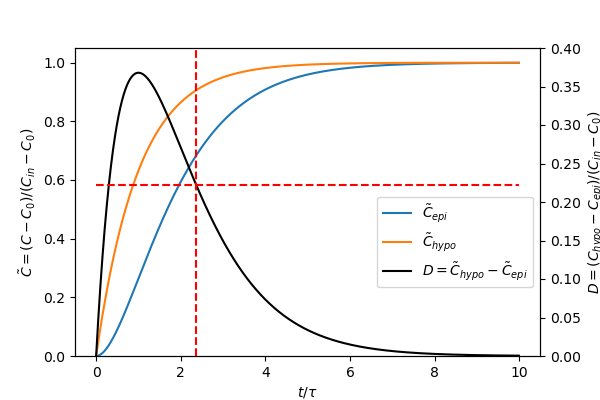

In [11]:
fig,ax=plt.subplots(1,1,figsize=(6,4))
p1,=ax.plot(t_ratio,Cepi_nondim(t_ratio),'-')
p2,=ax.plot(t_ratio,Chypo_nondim(t_ratio),'-')
ax.set_ylim(0,1.05)
ax_right = ax.twinx()
p3,=ax_right.plot(t_ratio,Chypo_nondim(t_ratio)-Cepi_nondim(t_ratio),'k-')
ax_right.set_ylim(0,0.4)
ylimval=ax_right.get_ylim()
p4,=ax_right.plot(tf_val/tau_val*np.full((2,),1),ylimval,'r--')
p5,=ax_right.plot(t_ratio[np.array([0,-1])],Dconc_val*np.full((2,),1),'r--')
lg=ax.legend([p1,p2,p3],["$\\tilde{C}_{epi}$","$\\tilde{C}_{hypo}$","$D=\\tilde{C}_{hypo}-\\tilde{C}_{epi}$"],loc="lower right",bbox_to_anchor=(1,0.2))
ax.set_xlabel("$t/\\tau$")
ax.set_ylabel("$\\tilde{C}=(C-C_0)/(C_{in}-C_0)$")
ax_right.set_ylabel("$D=(C_{hypo}-C_{epi})/(C_{in}-C_0)$")

### Values of $C_0$ and $C_{in}$ for varying $C_{epi}$ and $C_{hypo}$

Equations (3) and (4) can be solved for $C_0$ and $C_{in}$ from known $C_{epi}(T)$ and $C_{hypo}(T)$ at time $t=T$:
$$C_{in}=C_{hypo}(T)+\frac{C_{hypo}(T)-C_{epi}(T)}{T/\tau}\quad (8)$$
$$C_{0}=C_{hypo}(T)+\frac{C_{hypo}(T)-C_{epi}(T)}{T/\tau}\left(1-e^{T/\tau}\right)\quad (9)$$

In [12]:
def Cin_solution(Cepi,Chypo,t_ratio):
    return Chypo+(Chypo-Cepi)/t_ratio

In [13]:
def C0_solution(Cepi,Chypo,t_ratio):
    return Chypo+(Chypo-Cepi)/t_ratio*(1-np.exp(t_ratio))

In [14]:
Cepi_array=np.arange(0.4,0.7,0.01)
Chypo_array=np.arange(0.6,0.9,0.01)

In [15]:
Cin_array=np.full((len(Cepi_array),len(Chypo_array)),np.nan)
C0_array=np.full((len(Cepi_array),len(Chypo_array)),np.nan)

In [16]:
for kepi in range(len(Cepi_array)):
    for khypo in range(len(Chypo_array)):
        Cin_sol=Cin_solution(Cepi_array[kepi],Chypo_array[khypo],tf_val/tau_val)
        C0_sol=C0_solution(Cepi_array[kepi],Chypo_array[khypo],tf_val/tau_val)
        if (Cin_sol>0 and C0_sol>0) and Cin_sol>C0_sol:
            Cin_array[kepi,khypo]=Cin_sol
            C0_array[kepi,khypo]=C0_sol

Text(0.5, 1.0, '$C_{in}$')

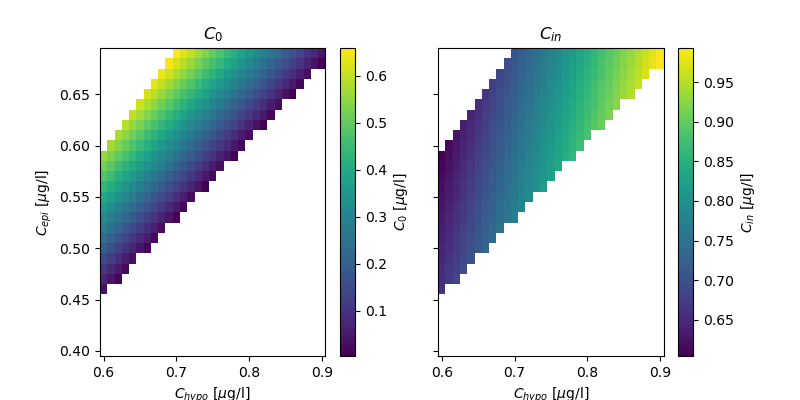

In [17]:
fig,ax=plt.subplots(1,2,figsize=(8,4),sharex=True,sharey=True)

pC0=ax[0].pcolormesh(Chypo_array,Cepi_array,C0_array)
fig.colorbar(pC0,label="$C_0$ [$\mu$g/l]")
xlimval=ax[0].get_xlim()
ax[0].set_xlabel("$C_{hypo}$ [$\mu$g/l]")
ax[0].set_ylabel("$C_{epi}$ [$\mu$g/l]")
ax[0].set_title("$C_0$")

pCin=ax[1].pcolormesh(Chypo_array,Cepi_array,Cin_array)
fig.colorbar(pCin,label="$C_{in}$ [$\mu$g/l]")
ax[1].set_xlabel("$C_{hypo}$ [$\mu$g/l]")
ax[1].set_title("$C_{in}$")

### Plot future concentrations if no input

We set the initial condition based on the measured triazole profile and $C_{in}=0$ to see how long it takes to reach concentrations below 0.1 µg/l.

In [18]:
depth_therm=150
C0e=np.mean(conc_interp[depth_interp<depth_therm])
C0h=np.mean(conc_interp[depth_interp>depth_therm])
Cin=0
C_thresh=0.1
t_ratio=np.arange(0,10,1/100) # t/tau

In [19]:
Cepi_future=Cepi(t_ratio,C0e,C0h,Cin)
Chypo_future=Chypo(t_ratio,C0h,Cin)
t_ratio_thresh=t_ratio[np.where(Cepi_future<C_thresh)[0][0]]
print("Time to reach threshold: t/tau={}".format(t_ratio_thresh))

Time to reach threshold: t/tau=3.58


Text(0, 0.5, 'C [$\\mu$g/l]')

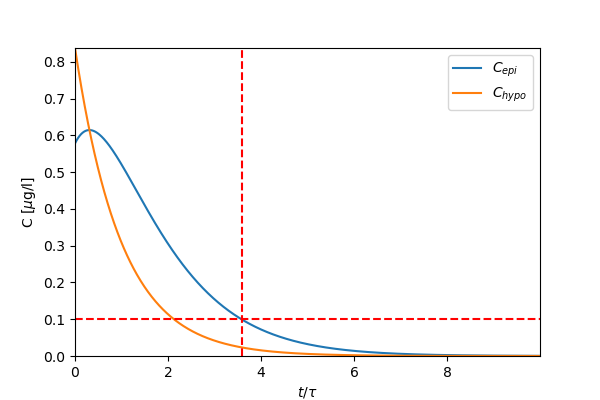

In [20]:
fig,ax=plt.subplots(1,1,figsize=(6,4))
p1,=ax.plot(t_ratio,Cepi_future,'-')
p2,=ax.plot(t_ratio,Chypo_future,'-')
ax.plot(t_ratio[np.array([0,-1])],C_thresh*np.full((2,),1),'--r')
ax.set_ylim(0,C0h)
ax.set_xlim(t_ratio[0],t_ratio[-1])
ylimval=ax.get_ylim()
ax.plot(t_ratio_thresh*np.full((2,),1),ylimval,'--r')
ax.legend([p1,p2],["$C_{epi}$","$C_{hypo}$"])
ax.set_xlabel("$t/\\tau$")
ax.set_ylabel("C [$\mu$g/l]")